In [5]:
#Project Overview
#This set of indicators is analyzed from four dimensions: profitability, earnings quality, 
#shareholder returns, and valuation judgment.
#This project analyzes Microsoft’s 2021–2025 financial trends and valuation

In [6]:
##Problem Definition：To analyze a firm’s long-term financial performance and market valuation 
#by extracting and integrating corporate fundamentals and stock price data 
#calculating key financial indicators, and visualizing trends to identify patterns in profitability, earnings, 
#and valuation dynamics.

In [7]:
##This code establishes a complete financial analysis pipeline that
#1.extracts annual firm fundamentals from Compustat and year-end stock prices from CRSP via WRDS
#2.calculates core profitability, cash flow, EPS, and share repurchase indicators,
#integrates market data to compute P/E ratio, 
#3.generates multiple visualizations to reveal trends in profitability, earnings,
#and valuation in a clear and comparable way.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import MinMaxScaler
import wrds

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [9]:
def get_compustat_data(ticker, start_year, end_year, wrds_conn):
    """Fetch firm annual financial data from Compustat (revenue, profit, equity, shares, repurchases, etc.)"""
    sql = f"""
    SELECT
        fyear AS year,
        tic,
        revt AS revenue,                
        gp AS gross_profit,             
        ni AS net_income,               
        csho AS shares_outstanding,     
        ceq AS common_equity,           
        oancf AS operating_cash_flow,   
        capxv AS capex,                 
        prstkc AS share_repurchase,     
        epsfx AS eps                    
    FROM comp.funda
    WHERE tic = '{ticker}'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND indfmt = 'INDL'
      AND consol = 'C'
      AND fyear BETWEEN {start_year} AND {end_year}
    ORDER BY fyear
    """
    df = wrds_conn.raw_sql(sql)
    return df


def get_crsp_price(ticker_cusip, start_year, end_year, wrds_conn):
    """
    Get year-end closing price from CRSP (last trading day of December)
    ticker_cusip: CUSIP code of the stock
    """
    sql = f"""
    SELECT
        EXTRACT(YEAR FROM date) AS year,
        prc
    FROM crsp.msf
    WHERE cusip = '{ticker_cusip}'
      AND EXTRACT(MONTH FROM date) = 12
      AND date BETWEEN '{start_year}-01-01' AND '{end_year}-12-31'
    ORDER BY date
    """
    df = wrds_conn.raw_sql(sql)
    df = df.groupby('year', as_index=False).last()
    df['year_end_price'] = df['prc'].abs()
    df = df[['year', 'year_end_price']]
    return df

In [10]:
def compute_indicators(df_fin):
    """
    Calculate core financial metrics from raw financial data:
    - Gross margin = Gross profit / Operating revenue
    - Net profit margin = Net income / Operating revenue
    - ROE = Net income / Common equity
    - FCF = Operating cash flow - Capital expenditure
    - Repurchase per share = Total repurchases / Number of shares
    - P/E ratio = Year-end stock price / EPS
    """
    df = df_fin.copy()

    df['gross_margin'] = df['gross_profit'] / df['revenue']
    df['net_margin'] = df['net_income'] / df['revenue']
    df['roe'] = df['net_income'] / df['common_equity']
    df['free_cash_flow'] = df['operating_cash_flow'] - df['capex']
    df['buyback_per_share'] = df['share_repurchase'] / df['shares_outstanding']

    if 'eps' not in df.columns or df['eps'].isna().all():
        df['eps'] = df['net_income'] / df['shares_outstanding']

    df['gross_margin_pct'] = (df['gross_margin'] * 100).round(2)
    df['net_margin_pct'] = (df['net_margin'] * 100).round(2)
    df['roe_pct'] = (df['roe'] * 100).round(2)

    return df


def merge_price_pe(df_indicators, df_price):
    """Merge year-end stock prices and calculate P/E ratio"""
    df = df_indicators.merge(df_price, on='year', how='left')
    df['pe_ratio'] = df['year_end_price'] / df['eps']
    df['pe_ratio'] = df['pe_ratio'].round(2)
    return df

In [11]:
def plot_profitability_trend(df):
    """Figure 1: Trends of gross margin, net profit margin, and ROE"""
    plt.figure()
    plt.plot(df['year'], df['gross_margin_pct'], marker='o', linewidth=2, label='Gross Margin (%)')
    plt.plot(df['year'], df['net_margin_pct'], marker='s', linewidth=2, label='Net Margin (%)')
    plt.plot(df['year'], df['roe_pct'], marker='^', linewidth=2, label='ROE (%)')
    plt.title('Core Profitability Trends', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('Percentage (%)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_eps_bar(df):
    """Figure 2: Bar chart of EPS"""
    plt.figure()
    plt.bar(df['year'], df['eps'], color='#c0392b', alpha=0.8)
    plt.title('Earnings Per Share (EPS)', fontsize=14)
    plt.xlabel('Year')
    plt.ylabel('EPS (USD/share)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_price_pe_trend(df):
    """Figure 3: Year-end stock price and P/E ratio trends"""
    fig, ax1 = plt.subplots()
    color1 = '#2980b9'
    ax1.plot(df['year'], df['year_end_price'], marker='o', linewidth=2, color=color1, label='Year-end Price (USD)')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Price (USD)', color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(alpha=0.3)

    ax2 = ax1.twinx()
    color2 = '#e67e22'
    ax2.plot(df['year'], df['eps'], marker='s', linewidth=2, color=color2, label='EPS (USD)')
    ax2.plot(df['year'], df['pe_ratio'], marker='^', linewidth=2, color='green', label='P/E Ratio')
    ax2.set_ylabel('EPS / P/E', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)

    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.title('Stock Price, EPS & P/E Trend')
    plt.tight_layout()
    plt.show()


def plot_normalized_comparison(df):
    """Figure 4: Normalized comparison of four core indicators (ROE, net margin, EPS, P/E)"""
    norm_df = df[['year', 'roe_pct', 'net_margin_pct', 'eps', 'pe_ratio']].copy()
    scaler = MinMaxScaler()
    norm_df[['roe', 'net_margin', 'eps_norm', 'pe']] = scaler.fit_transform(
        norm_df[['roe_pct', 'net_margin_pct', 'eps', 'pe_ratio']]
    )
    plt.figure()
    plt.plot(norm_df['year'], norm_df['roe'], marker='o', label='ROE (norm)')
    plt.plot(norm_df['year'], norm_df['net_margin'], marker='s', label='Net Margin (norm)')
    plt.plot(norm_df['year'], norm_df['eps_norm'], marker='^', label='EPS (norm)')
    plt.plot(norm_df['year'], norm_df['pe'], marker='d', label='P/E (norm)')
    plt.title('Normalized Comparison of Four Core Indicators')
    plt.xlabel('Year')
    plt.ylabel('Normalized Value (0-1)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [12]:
def analyze_company(ticker, start_year, end_year, wrds_username, cusip=None):
    """
    Full analysis pipeline
    ticker: Stock ticker (e.g., 'AAPL', 'MSFT')
    start_year, end_year: Year range for analysis
    wrds_username: WRDS username
    cusip: Optional, CUSIP code used by CRSP
    """
    import wrds
    db = wrds.Connection(wrds_username=wrds_username)

    print(f"Fetching Compustat data for {ticker}...")
    df_fin = get_compustat_data(ticker, start_year, end_year, db)

    if df_fin.empty:
        print(f"No Compustat data found for {ticker} between {start_year}-{end_year}")
        db.close()
        return

    df_indicators = compute_indicators(df_fin)

    if cusip is None:
        cusip_map = {'AAPL': '03783310', 'MSFT': '59491810', 'GOOGL': '38259P508', 'AMZN': '023135106'}
        if ticker.upper() in cusip_map:
            cusip = cusip_map[ticker.upper()]
        else:
            print(f"Warning: No CUSIP provided for {ticker}. Skipping valuation analysis.")
            df_price = pd.DataFrame(columns=['year', 'year_end_price'])
    else:
        print(f"Fetching CRSP price data for CUSIP {cusip}...")
        df_price = get_crsp_price(cusip, start_year, end_year, db)

    if not df_price.empty:
        df_final = merge_price_pe(df_indicators, df_price)
    else:
        df_final = df_indicators.copy()
        df_final['year_end_price'] = np.nan
        df_final['pe_ratio'] = np.nan

    db.close()

    print(f"\n--- Financial Indicators for {ticker.upper()} ---")
    core_cols = ['year', 'revenue', 'net_income', 'gross_margin_pct', 'net_margin_pct', 'roe_pct', 'eps']
    print(df_final[core_cols].to_markdown(index=False, floatfmt=".2f"))

    plot_profitability_trend(df_final)
    plot_eps_bar(df_final)
    if not df_price.empty:
        plot_price_pe_trend(df_final)
    plot_normalized_comparison(df_final)

    return df_final

Loading library list...
Done
Fetching Compustat data for MSFT...
Fetching CRSP price data for CUSIP 59491810...

--- Financial Indicators for MSFT ---
|   year |   revenue |   net_income |   gross_margin_pct |   net_margin_pct |   roe_pct |   eps |
|-------:|----------:|-------------:|-------------------:|-----------------:|----------:|------:|
|   2021 | 168088.00 |     61271.00 |              75.41 |            36.45 |     43.15 |  8.05 |
|   2022 | 198270.00 |     72738.00 |              75.77 |            36.69 |     43.68 |  9.65 |
|   2023 | 211915.00 |     72361.00 |              75.36 |            34.15 |     35.09 |  9.68 |
|   2024 | 245122.00 |     88136.00 |              77.92 |            35.96 |     32.83 | 11.80 |
|   2025 | 281724.00 |    101832.00 |              78.76 |            36.15 |     29.65 | 13.64 |


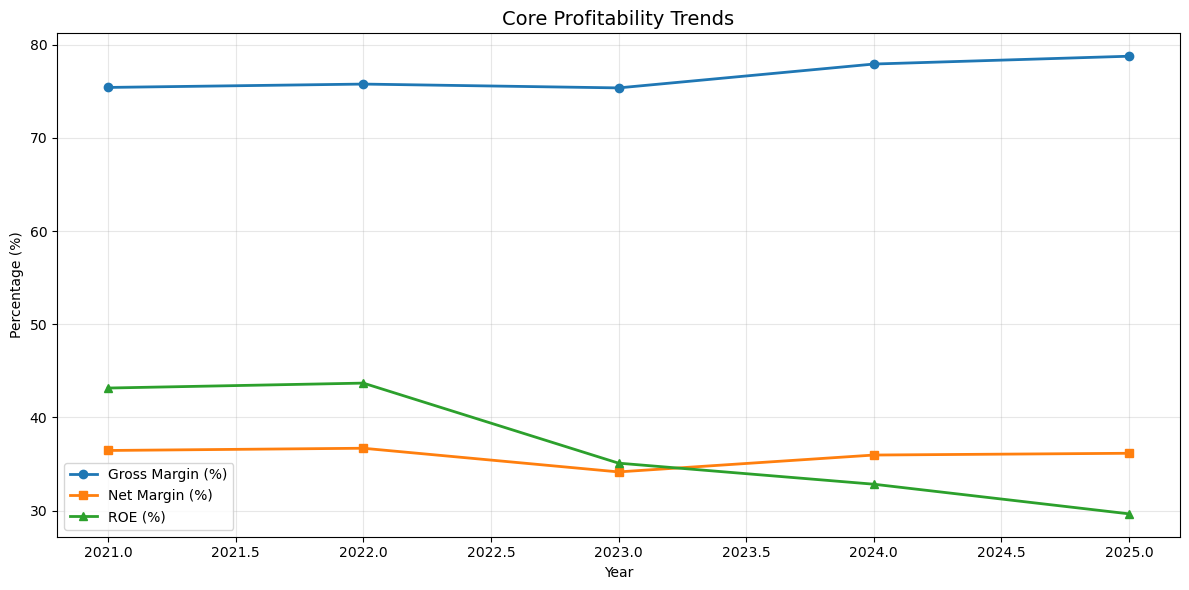

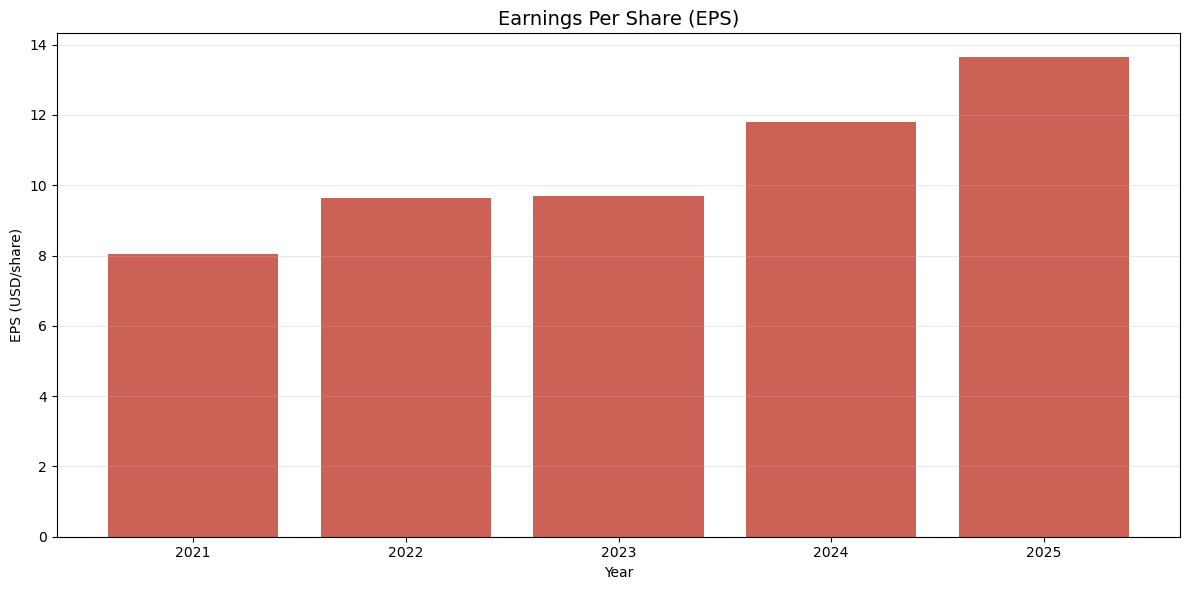

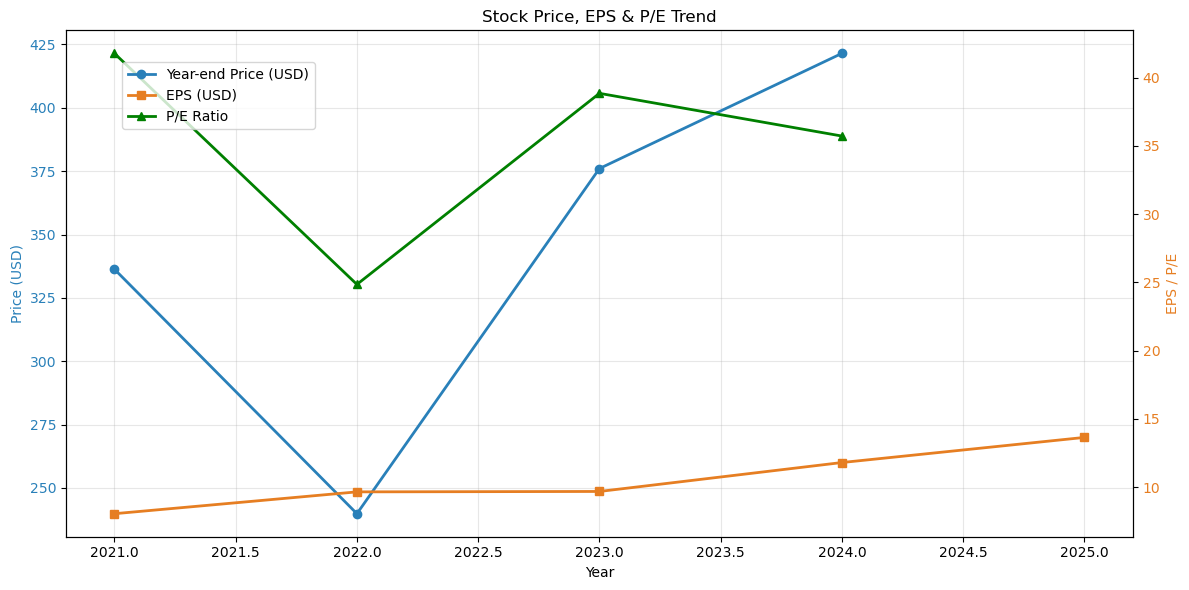

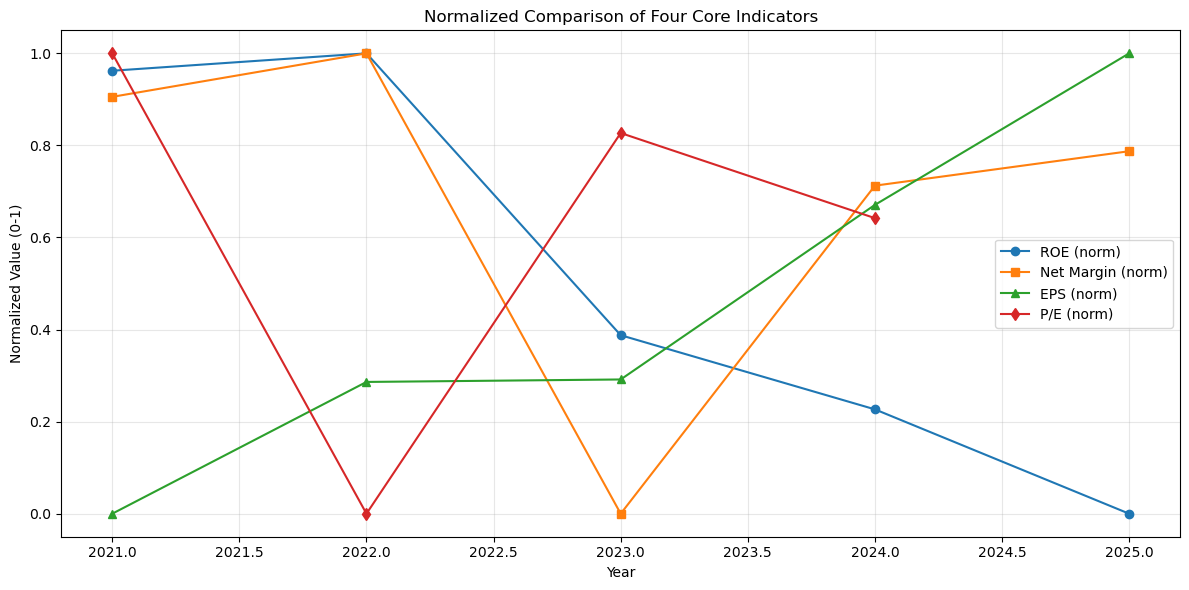

In [13]:
WRDS_USER = "luojiayi"

#Analysis of Microsoft Corporation
ticker = "MSFT"
cusip = "59491810"
start_year = 2021
end_year = 2025

#Analysis of Apple Inc.
# ticker = "AAPL"
# cusip = "03783310"   # Apple的CUSIP
# start = 2021
# end = 2025

#

# excucate 
result_df = analyze_company(ticker, start_year, end_year, WRDS_USER, cusip)